In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [2]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

In [ ]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # π dynamics
    omega0,
    rho,
    omega_y,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    harmonics,
    period,
    y,
    time_varying_parameters,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t
    - Persistent ARX logit π_t
    - Optional TVP for (gamma, xi, zeta)
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    n_eff = T - K

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # ===== 1. Update TVP parameters FIRST =====
        if i > 0:
            gamma[i] = gamma[i-1]
            xi[i] = xi[i-1]
            zeta[i] = zeta[i-1]

            if 2 in time_varying_parameters:
                gamma[i] += kappas_tvp[1] * score_gamma[i-1]
            if 3 in time_varying_parameters:
                xi[i] += kappas_tvp[2] * score_xi[i-1]
            if 4 in time_varying_parameters:
                zeta[i] += kappas_tvp[3] * score_zeta[i-1]

        # validity
        if np.exp(zeta[i]) <= np.exp(gamma[i]):
            return 1e12

        # ===== 2. φ dynamics =====
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # ===== 3. π dynamics =====
        y_lags = y[t-K:t][::-1]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ===== 4. Likelihood =====
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t],
                    phi=phi[i],
                    gamma=gamma[i],
                    xi=xi[i],
                    zeta=zeta[i],
                )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ===== 5. Scores =====
        if y[t] > 0:
            scores = gb2.score(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
        else:
            score_phi[i] = 0.0
            score_gamma[i] = 0.0
            score_xi[i] = 0.0
            score_zeta[i] = 0.0

        # ===== 6. GAS update for φ =====
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ===== 7. Seasonal φ =====
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = np.cos(lam) * g + np.sin(lam) * gs + kappa_gamma_phi * score_phi[i]
            gamma_star_phi[j] = np.cos(lam) * gs - np.sin(lam) * g + kappa_gamma_phi * score_phi[i]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [21]:
def objective_zagb2(theta, y, K, tvp = [], harmonics=10, period=365):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    if len(tvp) > 0:
        for i, v in enumerate(tvp): 
            kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,
        mode="loglik"
    )


In [ ]:
def AIC_zagb2(theta, y, K, tvp=[], harmonics=10, period=365):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    if len(tvp) > 0:
        for i, v in enumerate(tvp): 
            kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    loglik = -iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,
        mode="loglik"
    )
    
    return 2 * (len(theta) - loglik)


In [58]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
harmonics = 10
period = 365.25

aics = {}
results = {}

for i,file in enumerate(os.listdir(INPUT)):
    
    loc = file.split("_")[-2]
     
    if file.split("_")[-1] == "train.csv":
        
        print("Working on " + loc)
        
        aics[loc] = []
        results[loc] = []
        
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])
        
        y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values
        
        for tvp in [[], [3]]:
            
            print("Model = " + str([1] + tvp))
            
            if len(tvp) > 0:
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        0.5,        # c_phi
                        0.95,       # alpha_phi
                        0.01,       # kappa_phi
                        *[0.01],#, 0.01],
                        0.01,       # kappa_gamma_phi

                        -1.0,       # omega0
                        0.5,        # rho

                        0.01, 0.01, 0.01,   # omega_y (K=3)

                        1.2,        # gamma
                        1.2,        # xi
                        5.0         # zeta
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics)         # gamma_star0_phi
                ])
            
                bounds = [
                        (-2.0, 4.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha_phi
                        (1e-4, 0.1),     # kappa_phi
                        *[(1e-4, 0.1)],#, (1e-4, 0.1)],#, (-0.1, 0.1), (-0.1, 0.1)],
                        (1e-4, 0.1),     # kappa_gamma_phi

                        (-10.0, 2.0),    # omega0
                        (0.00, 0.99),   # rho

                    ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics
            else:
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        0.5,        # c_phi
                        0.95,       # alpha_phi
                        0.01,       # kappa_phi
                        0.01,       # kappa_gamma_phi

                        -1.0,       # omega0
                        0.5,        # rho

                        0.01, 0.01, 0.01,   # omega_y (K=3)

                        1.2,        # gamma
                        1.2,        # xi
                        5.0         # zeta
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics)         # gamma_star0_phi
                ])
            
                bounds = [
                        (-2.0, 4.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha_phi
                        (1e-4, 0.1),     # kappa_phi
                        (1e-4, 0.1),     # kappa_gamma_phi

                        (-10.0, 2.0),    # omega0
                        (0.00, 0.99),   # rho

                    ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, 3, tvp, harmonics, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )
            
            results[loc].append(res)
            aics[loc].append(AIC_zagb2(res.x, y, 3, tvp=tvp, harmonics=10, period=365.25))

Working on BELO HORIZONTE
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\1664475222.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on CRUZEIRO DO SUL (ACRE)
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\1664475222.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on GARANHUNS (PERNAMBUCO)
Model = [1]


...

Model = [1, 3]
Working on SALVADOR
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\1664475222.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on SÃO PAULO
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\1664475222.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]


In [59]:
aics

{'BELO HORIZONTE': [np.float64(11372.778497113335),
  np.float64(11298.024274803594)],
 'CRUZEIRO DO SUL (ACRE)': [np.float64(18724.43547891161),
  np.float64(17682.816095950708)],
 'GARANHUNS (PERNAMBUCO)': [np.float64(13345.504455945333),
  np.float64(13286.444876546704)],
 'MACEIÓ': [np.float64(16720.88817150315), np.float64(16724.121871461924)],
 'MANAUS': [np.float64(19897.4522238842), np.float64(18545.25994027804)],
 'RIO DE JANEIRO (INMET)': [np.float64(13578.895704587027),
  np.float64(12816.151593220446)],
 'SALVADOR': [np.float64(17094.45589573621), np.float64(16928.97271584465)],
 'SÃO PAULO': [np.float64(13843.789214870483), np.float64(13555.789122674922)]}

In [42]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)


In [ ]:
idx = 0
K = 3

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1

kappa_xi_tvp = res.x[idx]; idx+=1

kappa_gamma_phi = res.x[idx]; idx+=1

omega0 = res.x[idx]; idx+=1
rho = res.x[idx]; idx+=1

omega_y = res.x[idx:idx+K]; idx+=K

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+harmonics]; idx+=harmonics
gamma_star0_phi = res.x[idx:idx+harmonics]


In [2]:
tvp = []

out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma0_phi=gamma0_phi,
    gamma_star0_phi=gamma_star0_phi,
    alpha_phi=alpha_phi,
    kappa_phi=kappa_phi,
    kappas_tvp=[0, 0, kappa_xi_tvp, 0],#, kappa_zeta_tvp],
    c_phi=c_phi,
    kappa_gamma_phi=kappa_gamma_phi,

    omega0=omega0,
    rho=rho,
    omega_y=omega_y,

    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,

    harmonics=harmonics,
    period=period,
    y=y,
    time_varying_parameters=tvp,   # ← IMPORTANT
    mode="filter"
)


NameError: name 'iterate_zagb2' is not defined

In [199]:
out

{'phi': array([2.70552505, 3.23819346, 3.12019617, ..., 2.93125837, 2.91530638,
        2.89524094], shape=(3647,)),
 'gamma': array([1.19206888, 1.19206888, 1.19206888, ..., 1.19206888, 1.19206888,
        1.19206888], shape=(3647,)),
 'xi': array([1.21542245, 1.21542245, 1.21542245, ..., 1.21542245, 1.21542245,
        1.21542245], shape=(3647,)),
 'zeta': array([4.97360727, 4.97360727, 4.97360727, ..., 4.97360727, 4.97360727,
        4.97360727], shape=(3647,)),
 'pi': array([0.30412938, 0.27608009, 0.20044216, ..., 0.17136206, 0.16281846,
        0.15623131], shape=(3647,)),
 'eta': array([-0.82771054, -0.96398974, -1.38353313, ..., -1.57600471,
        -1.6374051 , -1.68654071], shape=(3647,)),
 'mu_phi': array([2.67008238, 2.61900003, 2.45143265, ..., 1.79753155, 1.79969987,
        1.80142017], shape=(3647,)),
 'score_phi': array([11.68479672,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ], shape=(3647,))}

In [166]:
print("mu0_phi:", mu0_phi, "gamma0_phi:", gamma0_phi, "gamma_star0_phi:", gamma_star0_phi, "alpha_phi:", alpha_phi, "kappa_phi:", kappa_phi, "kappas_tvp:", [kappa_gamma_tvp], "c_phi:", c_phi, "kappa_gamma_phi:", kappa_gamma_phi, "omega0:", omega0, "rho:", rho, "omega_y:", omega_y, "gamma_init:", gamma_init, "xi_init:", xi_init, "zeta_init:", zeta_init, "gamma0_phi:", gamma0_phi, "gamma_star0_phi:", gamma_star0_phi)

mu0_phi: 2.6700823846401436 gamma0_phi: [-0.0045236   0.00756159  0.00402591  0.00589929  0.00592702 -0.0036815
  0.00522918  0.00491579  0.00478638  0.0053026 ] gamma_star0_phi: [ 0.00414601 -0.00634513 -0.00410227 -0.0055077   0.00421107  0.00287783
 -0.00497787  0.00421977 -0.00481017 -0.00482797] alpha_phi: 0.793375265485598 kappa_phi: 0.010872238817850497 kappas_tvp: [np.float64(0.005607082907639546)] c_phi: 0.3735828051756261 kappa_gamma_phi: 0.005012173730914656 omega0: -0.9534136471516116 rho: 0.44773713408532556 omega_y: [ 0.09033964 -0.01213599  0.00832476] gamma_init: 1.1920688753699327 xi_init: 1.2154224467741601 zeta_init: 4.973607269529821 gamma0_phi: [-0.0045236   0.00756159  0.00402591  0.00589929  0.00592702 -0.0036815
  0.00522918  0.00491579  0.00478638  0.0053026 ] gamma_star0_phi: [ 0.00414601 -0.00634513 -0.00410227 -0.0055077   0.00421107  0.00287783
 -0.00497787  0.00421977 -0.00481017 -0.00482797]


In [ ]:
phi_hat = out["phi"]
pi_hat  = out["pi"]
gamma_hat = out["gamma"]
xi_hat = out["xi"]
zeta_hat = out["zeta"]

y_eff = y[K:]

pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    if y_eff[t] == 0:
        pit[t] = rng.uniform(0.0, 1.0 - pi_hat[t])
    else:
        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat[t]
        )
        pit[t] = (1 - pi_hat[t]) + pi_hat[t] * F


NameError: name 'out' is not defined

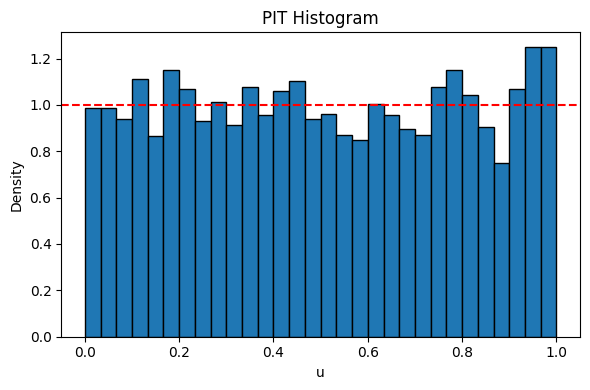

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

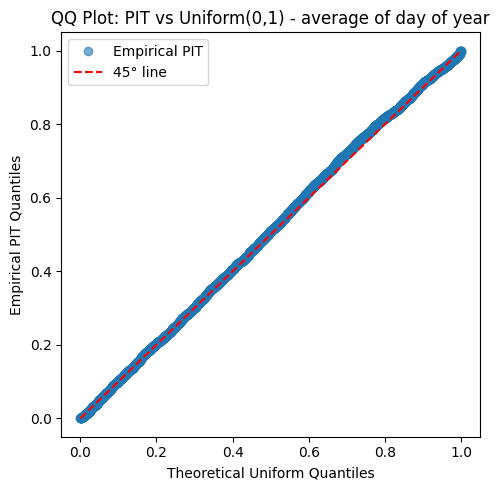

In [11]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - average of day of year")
plt.legend()
plt.tight_layout()
plt.show()


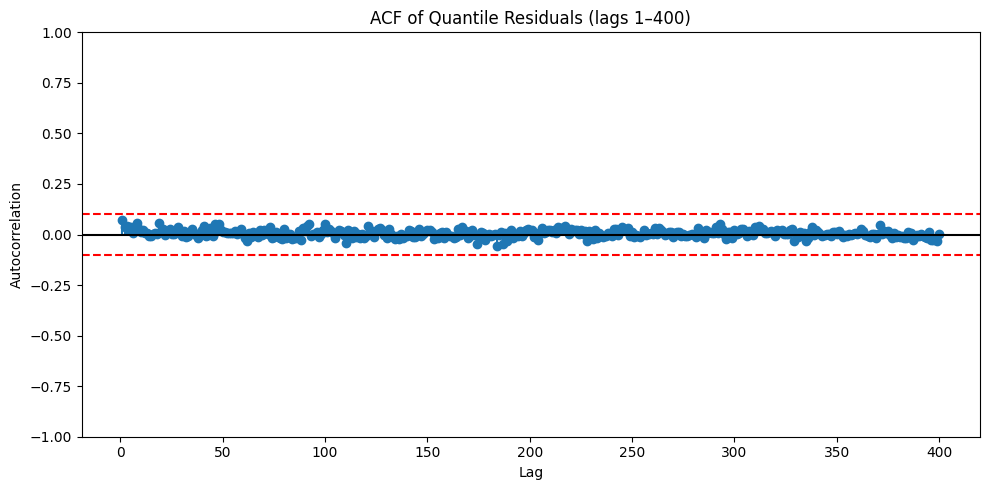

In [189]:
from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()


## Simulation

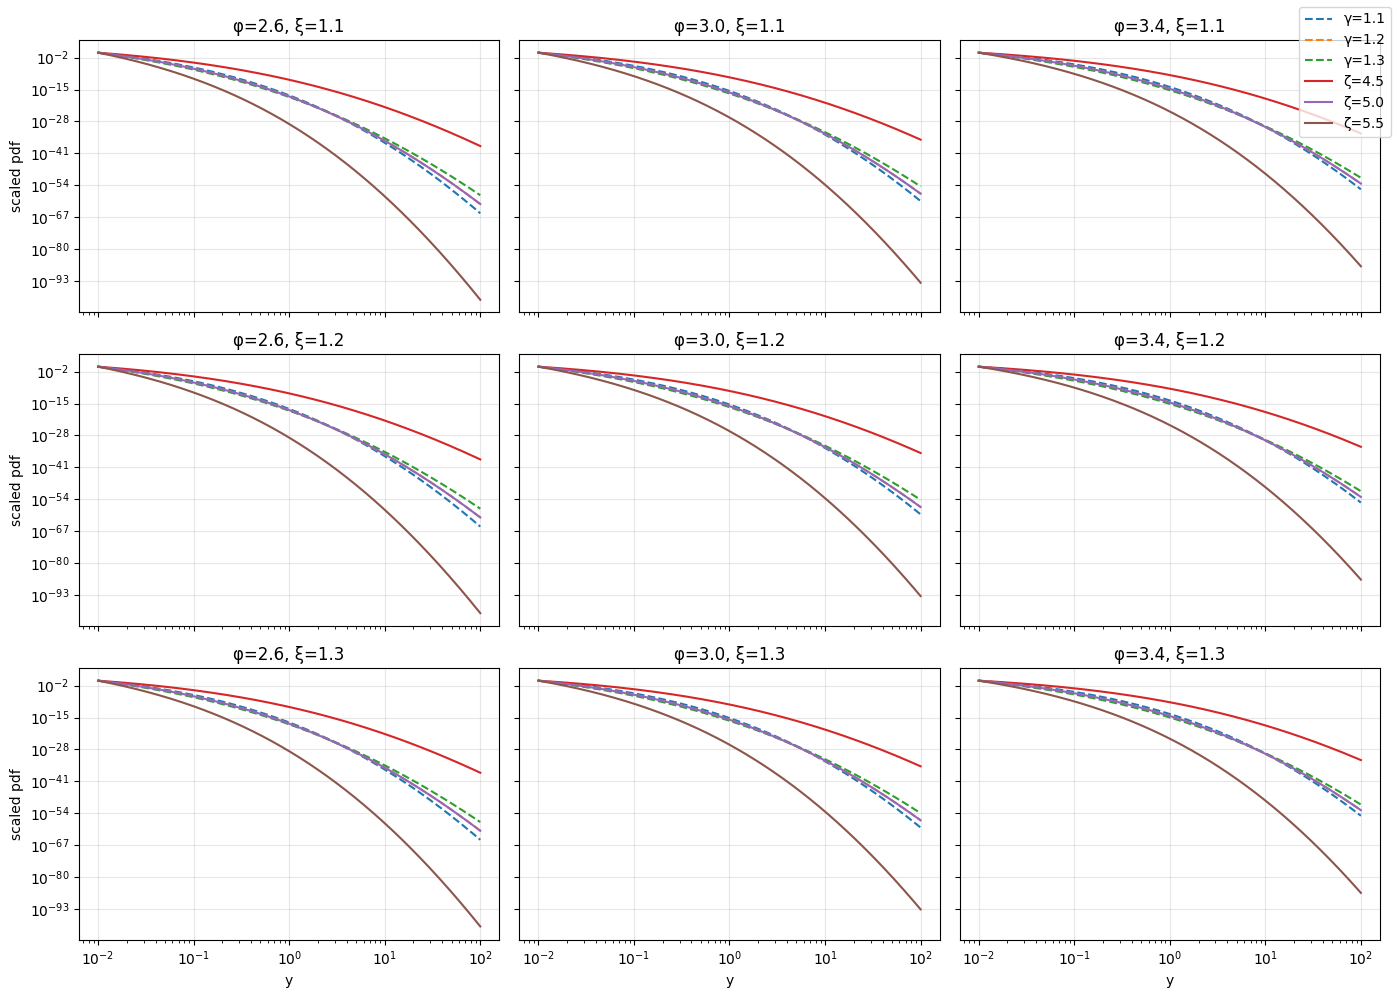

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta

# ------------------------
# GB2 pdf
# ------------------------
def gb2_pdf(y, phi, gamma, xi, zeta):
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p

    return (
        p
        * y**(a*p - 1)
        / (sigma**(a*p) * beta(a, b))
        * (1 + z) ** (-(a + b))
    )


# ------------------------
# parameter grid (close to your fit)
# ------------------------
phi_vals   = [2.6, 3.0, 3.4]
xi_vals    = [1.1, 1.2, 1.3]
gamma_vals = [1.1, 1.2, 1.3]   # dashed
zeta_vals  = [4.5, 5.0, 5.5]   # solid

# focus on rainfall-relevant region
y = np.logspace(-2, 2, 2000)


fig, axes = plt.subplots(len(xi_vals), len(phi_vals),
                         figsize=(14, 10),
                         sharex=True, sharey=True)

for r, xi in enumerate(xi_vals):
    for c, phi in enumerate(phi_vals):

        ax = axes[r, c]

        # dashed = gamma variation
        for g in gamma_vals:
            pdf = gb2_pdf(y, phi, g, xi, zeta_vals[1])
            pdf /= pdf.max()  # normalize for visibility
            ax.plot(y, pdf, "--", label=f"γ={g}")

        # solid = zeta variation
        for zeta in zeta_vals:
            pdf = gb2_pdf(y, phi, gamma_vals[1], xi, zeta)
            pdf /= pdf.max()
            ax.plot(y, pdf, "-", label=f"ζ={zeta}")

        ax.set_xscale("log")
        ax.set_yscale("log")      # KEY CHANGE
        ax.set_title(f"φ={phi}, ξ={xi}")
        ax.grid(alpha=0.3)

# labels
for ax in axes[-1]:
    ax.set_xlabel("y")

for ax in axes[:, 0]:
    ax.set_ylabel("scaled pdf")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


## Best Model

In [4]:
aics = {'BELO HORIZONTE': [np.float64(11372.778497113335),
  np.float64(11298.024274803594)],
 'CRUZEIRO DO SUL (ACRE)': [np.float64(18724.43547891161),
  np.float64(17682.816095950708)],
 'GARANHUNS (PERNAMBUCO)': [np.float64(13345.504455945333),
  np.float64(13286.444876546704)],
 'MACEIÓ': [np.float64(16720.88817150315), np.float64(16724.121871461924)],
 'MANAUS': [np.float64(19897.4522238842), np.float64(18545.25994027804)],
 'RIO DE JANEIRO (INMET)': [np.float64(13578.895704587027),
  np.float64(12816.151593220446)],
 'SALVADOR': [np.float64(17094.45589573621), np.float64(16928.97271584465)],
 'SÃO PAULO': [np.float64(13843.789214870483), np.float64(13555.789122674922)]}

In [9]:
df_aics = pd.DataFrame(aics).transpose()
df_aics.columns = ['Model Phi time-varying','Model Phi, Xi time-varying']
df_aics

,Model Phi time-varying,"Model Phi, Xi time-varying"
BELO HORIZONTE,11372.778497,11298.024275
CRUZEIRO DO SUL (ACRE),18724.435479,17682.816096
GARANHUNS (PERNAMBUCO),13345.504456,13286.444877
MACEIÓ,16720.888172,16724.121871
MANAUS,19897.452224,18545.259940
RIO DE JANEIRO (INMET),13578.895705,12816.151593
SALVADOR,17094.455896,16928.972716
SÃO PAULO,13843.789215,13555.789123


In [10]:
import numpy as np
import pandas as pd

df = df_aics.copy()

# -------------------------
# 1. percentage difference
# -------------------------
row_min = df.min(axis=1)
row_max = df.max(axis=1)

df["% diff (max→min)"] = 100 * (row_max - row_min) / np.abs(row_min)

# -------------------------
# 2. format with bold
# -------------------------
def format_row(row):
    values = row.iloc[:-1]  # only AIC columns
    min_val = values.min()

    out = []
    for v in values:
        if v == min_val:
            out.append(f"\\textbf{{{v:.2f}}}")
        else:
            out.append(f"{v:.2f}")

    out.append(f"{row.iloc[-1]:.2f}\\%")
    return pd.Series(out, index=row.index)

df_fmt = df.apply(format_row, axis=1)

# -------------------------
# 3. export latex
# -------------------------
latex_table = df_fmt.to_latex(
    escape=False,
    column_format="lccc",
    caption="Model comparison using AIC",
    label="tab:aic_comparison"
)

print(latex_table)


\begin{table}
\caption{Model comparison using AIC}
\label{tab:aic_comparison}
\begin{tabular}{lccc}
\toprule
 & Model Phi time-varying & Model Phi, Xi time-varying & % diff (max→min) \\
\midrule
BELO HORIZONTE & 11372.78 & \textbf{11298.02} & 0.66\% \\
CRUZEIRO DO SUL (ACRE) & 18724.44 & \textbf{17682.82} & 5.89\% \\
GARANHUNS (PERNAMBUCO) & 13345.50 & \textbf{13286.44} & 0.44\% \\
MACEIÓ & \textbf{16720.89} & 16724.12 & 0.02\% \\
MANAUS & 19897.45 & \textbf{18545.26} & 7.29\% \\
RIO DE JANEIRO (INMET) & 13578.90 & \textbf{12816.15} & 5.95\% \\
SALVADOR & 17094.46 & \textbf{16928.97} & 0.98\% \\
SÃO PAULO & 13843.79 & \textbf{13555.79} & 2.12\% \\
\bottomrule
\end{tabular}
\end{table}



## Model for $\phi$ and $\xi$ time-varying

In [144]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
harmonics = 10
period = 365.25

aics = {}
results = {}

for i,file in enumerate(os.listdir(INPUT)):
    
    loc = file.split("_")[-2]
     
    if file.split("_")[-1] == "train.csv":
        
        print("Working on " + loc)
        
        aics[loc] = []
        results[loc] = []
        
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])
        
        y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values
        
        for tvp in [[3]]:
            
            print("Model = " + str([1] + tvp))
            
            if len(tvp) > 0:
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        0.5,        # c_phi
                        0.95,       # alpha_phi
                        0.01,       # kappa_phi
                        *[0.01],#, 0.01],
                        0.01,       # kappa_gamma_phi

                        -1.0,       # omega0
                        0.5,        # rho

                        0.01, 0.01, 0.01,   # omega_y (K=3)

                        1.2,        # gamma
                        1.2,        # xi
                        5.0         # zeta
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics)         # gamma_star0_phi
                ])
            
                bounds = [
                        (-2.0, 4.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha_phi
                        (1e-4, 0.1),     # kappa_phi
                        *[(1e-4, 0.1)],#, (1e-4, 0.1)],#, (-0.1, 0.1), (-0.1, 0.1)],
                        (1e-4, 0.1),     # kappa_gamma_phi

                        (-10.0, 2.0),    # omega0
                        (0.00, 0.99),   # rho

                    ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics
            else:
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        0.5,        # c_phi
                        0.95,       # alpha_phi
                        0.01,       # kappa_phi
                        0.01,       # kappa_gamma_phi

                        -1.0,       # omega0
                        0.5,        # rho

                        0.01, 0.01, 0.01,   # omega_y (K=3)

                        1.2,        # gamma
                        1.2,        # xi
                        5.0         # zeta
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics)         # gamma_star0_phi
                ])
            
                bounds = [
                        (-2.0, 4.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha_phi
                        (1e-4, 0.1),     # kappa_phi
                        (1e-4, 0.1),     # kappa_gamma_phi

                        (-10.0, 2.0),    # omega0
                        (0.00, 0.99),   # rho

                    ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, 3, tvp, harmonics, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )
            
            results[loc].append(res)
            aics[loc].append(AIC_zagb2(res.x, y, 3, tvp=tvp, harmonics=10, period=365.25))

Working on BELO HORIZONTE
Model = [1, 3]


C:\Users\ilang\AppData\Local\Temp\ipykernel_31464\731169590.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on CRUZEIRO DO SUL (ACRE)
Model = [1, 3]


C:\Users\ilang\AppData\Local\Temp\ipykernel_31464\731169590.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on GARANHUNS (PERNAMBUCO)
Model = [1, 3]


...

C:\Users\ilang\AppData\Local\Temp\ipykernel_31464\731169590.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on SALVADOR
Model = [1, 3]


C:\Users\ilang\AppData\Local\Temp\ipykernel_31464\731169590.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on SÃO PAULO
Model = [1, 3]


C:\Users\ilang\AppData\Local\Temp\ipykernel_31464\731169590.py:111: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


## Std error

In [31]:
file in os.listdir(INPUT)[0]

df = pd.read_csv(os.path.join(INPUT, file), sep=";")
df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])

y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values

In [32]:
results['BELO HORIZONTE'][0].x

array([ 2.66705313e+00,  5.69582537e-01,  9.55079415e-01,  1.00000000e-01,
        2.28166497e-03,  1.28942021e-02, -8.95828971e-01,  3.35913940e-01,
        6.30230406e-02,  1.26478826e-03,  8.81747445e-03,  1.11072343e+00,
        1.21976108e+00,  4.95802161e+00,  1.37720260e-02,  8.48299461e-03,
        6.87067434e-03,  8.09307303e-03,  4.37561018e-03,  6.77576025e-03,
        6.04977817e-03,  7.79472213e-03,  8.68102012e-03,  7.24400896e-03,
       -2.85115171e-03, -4.31386378e-05, -2.93365793e-05, -3.35858540e-03,
       -2.08033601e-04, -5.58359929e-03,  2.13443768e-03, -4.11673117e-04,
        3.32134304e-04, -1.13363306e-03])

In [12]:
pip install numdifftools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
H_inv = results['BELO HORIZONTE'][0].hess_inv.todense()
se = np.sqrt(np.diag(H_inv))

In [35]:
se

array([1.01293201, 1.2068664 , 0.33493201, 3.75346826, 0.30795753,
       0.61748196, 1.58983857, 1.86309653, 1.92447621, 1.99339754,
       0.94431768, 1.80523891, 1.05609869, 1.17897935, 1.02957646,
       1.01065593, 1.00725304, 1.01043991, 1.00303572, 1.0078201 ,
       1.00538948, 1.00942812, 1.01152211, 1.0073878 , 1.00149809,
       1.00001238, 0.99999989, 1.00218588, 1.00000422, 1.00475746,
       1.00067426, 1.00000439, 0.99999856, 1.00015905])

In [33]:
results['BELO HORIZONTE'][0].jac

array([-4.60420593e-03, -3.70041551e-02, -2.63372545e-01, -3.57454289e-02,
       -4.76301665e-02,  5.89043925e-02,  1.90652826e-02, -3.27150085e-02,
       -1.29090294e-02, -5.14184251e-03, -1.17236221e-02,  5.32912162e-02,
       -1.25495393e-02,  1.95922613e-02, -7.94952992e-03, -3.57973651e-03,
       -3.46578322e-03, -4.44329018e-03, -2.21160867e-03, -4.32944791e-03,
       -2.51312304e-03, -3.96978006e-03, -4.46127579e-03, -2.87871949e-03,
        2.61191069e-03,  3.23896465e-04, -9.41469125e-05,  2.69511080e-03,
        6.19726492e-05,  3.10564907e-03, -8.57758309e-04,  2.90212299e-04,
        7.18802795e-04,  9.12980802e-04])

In [18]:
bounds = [
                        (-2.0, 4.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha_phi
                        (1e-4, 0.1),     # kappa_phi
                        (1e-4, 0.1),     # kappa_gamma_phi

                        (-10.0, 2.0),    # omega0
                        (0.00, 0.99),   # rho

                    ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics

In [ ]:
results['BELO HORIZONTE'][0].x

array([ 2.67786438e+00,  5.75725845e-01,  9.55527941e-01,  6.93935547e-02,
        4.24165116e-03,  1.19783196e-02, -8.99411745e-01,  3.81051239e-01,
        6.50060962e-02, -1.39942457e-02,  1.91259259e-02,  1.13660053e+00,
        1.23176685e+00,  4.94946560e+00,  1.40081941e-02,  1.07375283e-02,
        9.62376219e-03,  1.04822020e-02,  8.03334535e-03,  9.52518552e-03,
        9.16670103e-03,  1.02435101e-02,  1.07823592e-02,  9.88732954e-03,
       -7.07334318e-03,  5.16671709e-03,  5.19357948e-03, -5.89449298e-03,
       -5.26595239e-03, -8.66226323e-03,  6.69648394e-03, -5.29949850e-03,
        5.66671739e-03, -5.89910815e-03])

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def build_results_table(results, harmonics, K=3):

    latex_tables = {}

    for loc in results.keys():

        res = results[loc][0]  # assuming first model per location
        theta = res.x
        grad  = res.jac

        # Inverse Hessian
        try:
            H_inv = res.hess_inv.todense()
        except:
            H_inv = res.hess_inv

        se = np.sqrt(np.diag(H_inv))

        # t-stats and p-values (two-tailed normal approx)
        tvals = theta / se
        pvals = 2 * (1 - norm.cdf(np.abs(tvals)))

        # -------------------------------
        # Parameter names in correct order
        # -------------------------------
        names = []

        names += ["mu0\_phi"]
        names += ["c\_phi"]
        names += ["alpha\_phi"]
        names += ["kappa\_phi"]
        names += ["kappa\_xi\_tvp"]
        names += ["kappa\_gamma\_phi"]
        names += ["omega0"]
        names += ["rho"]

        for k in range(K):
            names += [f"omega\_y\_{k+1}"]

        names += ["gamma\_init"]
        names += ["xi\_init"]
        names += ["zeta\_init"]

        for h in range(harmonics):
            names += [f"gamma0\_phi\_{h+1}"]

        for h in range(harmonics):
            names += [f"gamma\_star0\_phi\_{h+1}"]

        # -------------------------------
        # Create dataframe
        # -------------------------------
        df = pd.DataFrame({
            "Parameter": names,
            "Estimate": theta,
            "Gradient": grad,
            "Std.Error": se,
            "t-value": tvals,
            "p-value": pvals
        })

        # Formatting
        df["Estimate"] = df["Estimate"].map(lambda x: f"{x:.6f}")
        df["Gradient"] = df["Gradient"].map(lambda x: f"{x:.3f}")
        df["Std.Error"] = df["Std.Error"].map(lambda x: f"{x:.6f}")
        df["t-value"] = df["t-value"].map(lambda x: f"{x:.3f}")
        df["p-value"] = df["p-value"].map(lambda x: f"{x:.4f}")

        # Convert to LaTeX
        latex_table = df.to_latex(
            index=False,
            escape=False,
            column_format="lccccc",
            caption=f"Parameter estimates for {loc}",
            label=f"tab:{loc.lower().replace(' ','_')}_results"
        )

        latex_tables[loc] = latex_table

    return latex_tables


<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:37: SyntaxWarning: invalid escape sequence '\_'
<>:42: SyntaxWarning: invalid escape sequence '\_'
<>:44: SyntaxWarning: invalid escape sequence '\_'
<>:45: SyntaxWarning: invalid escape sequence '\_'
<>:46: SyntaxWarning: invalid escape sequence '\_'
<>:49: SyntaxWarning: invalid escape sequence '\_'
<>:52: SyntaxWarning: invalid escape sequence '\_'
<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:37: SyntaxWarning: invalid escape sequence '\_'
<>:42: SyntaxWarning: invalid escape sequence '\_'
<>:44: SyntaxWarning: invalid e

In [40]:
latex_tables = build_results_table(results, harmonics=10, K=3)

for k in results.keys():
    print(latex_tables[k])


\begin{table}
\caption{Parameter estimates for BELO HORIZONTE}
\label{tab:belo_horizonte_results}
\begin{tabular}{lccccc}
\toprule
Parameter & Estimate & Gradient & Std.Error & t-value & p-value \\
\midrule
mu0\_phi & 2.667053 & -0.005 & 1.012932 & 2.633 & 0.0085 \\
c\_phi & 0.569583 & -0.037 & 1.206866 & 0.472 & 0.6370 \\
alpha\_phi & 0.955079 & -0.263 & 0.334932 & 2.852 & 0.0044 \\
kappa\_phi & 0.100000 & -0.036 & 3.753468 & 0.027 & 0.9787 \\
kappa\_xi\_tvp & 0.002282 & -0.048 & 0.307958 & 0.007 & 0.9941 \\
kappa\_gamma\_phi & 0.012894 & 0.059 & 0.617482 & 0.021 & 0.9833 \\
omega0 & -0.895829 & 0.019 & 1.589839 & -0.563 & 0.5731 \\
rho & 0.335914 & -0.033 & 1.863097 & 0.180 & 0.8569 \\
omega\_y\_1 & 0.063023 & -0.013 & 1.924476 & 0.033 & 0.9739 \\
omega\_y\_2 & 0.001265 & -0.005 & 1.993398 & 0.001 & 0.9995 \\
omega\_y\_3 & 0.008817 & -0.012 & 0.944318 & 0.009 & 0.9925 \\
gamma\_init & 1.110723 & 0.053 & 1.805239 & 0.615 & 0.5384 \\
xi\_init & 1.219761 & -0.013 & 1.056099 & 1.155 & 0.

### Quantile residuals

In [98]:
quant = []
pits = []

In [102]:
quant = []
pis = []

for k, result in results.items():
    
    res = result[0]
    
    idx = 0
    K = 3

    mu0_phi = res.x[idx]; idx+=1
    c_phi = res.x[idx]; idx+=1
    alpha_phi = res.x[idx]; idx+=1
    kappa_phi = res.x[idx]; idx+=1

    kappa_xi_tvp = res.x[idx]; idx+=1

    kappa_gamma_phi = res.x[idx]; idx+=1

    omega0 = res.x[idx]; idx+=1
    rho = res.x[idx]; idx+=1

    omega_y = res.x[idx:idx+K]; idx+=K

    gamma_init = res.x[idx]; idx+=1
    xi_init = res.x[idx]; idx+=1
    zeta_init = res.x[idx]; idx+=1

    gamma0_phi = res.x[idx:idx+harmonics]; idx+=harmonics
    gamma_star0_phi = res.x[idx:idx+harmonics]
    
    tvp = [3]

    out = iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=[0, 0, kappa_xi_tvp, 0],#, kappa_zeta_tvp],
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma_init=gamma_init,
        xi_init=xi_init,
        zeta_init=zeta_init,

        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,   # ← IMPORTANT
        mode="filter"
    )
    
    phi_hat = out["phi"]
    pi_hat  = out["pi"]
    gamma_hat = out["gamma"]
    xi_hat = out["xi"]
    zeta_hat = out["zeta"]
    
    pis.append(pi_hat)

    y_eff = y[K:]

    pit = np.zeros(len(y_eff))
    rng = np.random.default_rng(123)

    for t in range(len(y_eff)):

        if y_eff[t] == 0:
            pit[t] = rng.uniform(0.0, 1.0 - pi_hat[t])
        else:
            F = gb2_cdf(
                y_eff[t],
                phi_hat[t],
                gamma_hat[t],
                xi_hat[t],
                zeta_hat[t]
            )
            pit[t] = (1 - pi_hat[t]) + pi_hat[t] * F
            
    eps = 1e-10
    pit = np.clip(pit, eps, 1 - eps)
    

    pits.append(pit)
    qr = norm.ppf(pit[3:])
    quant.append(qr)
   

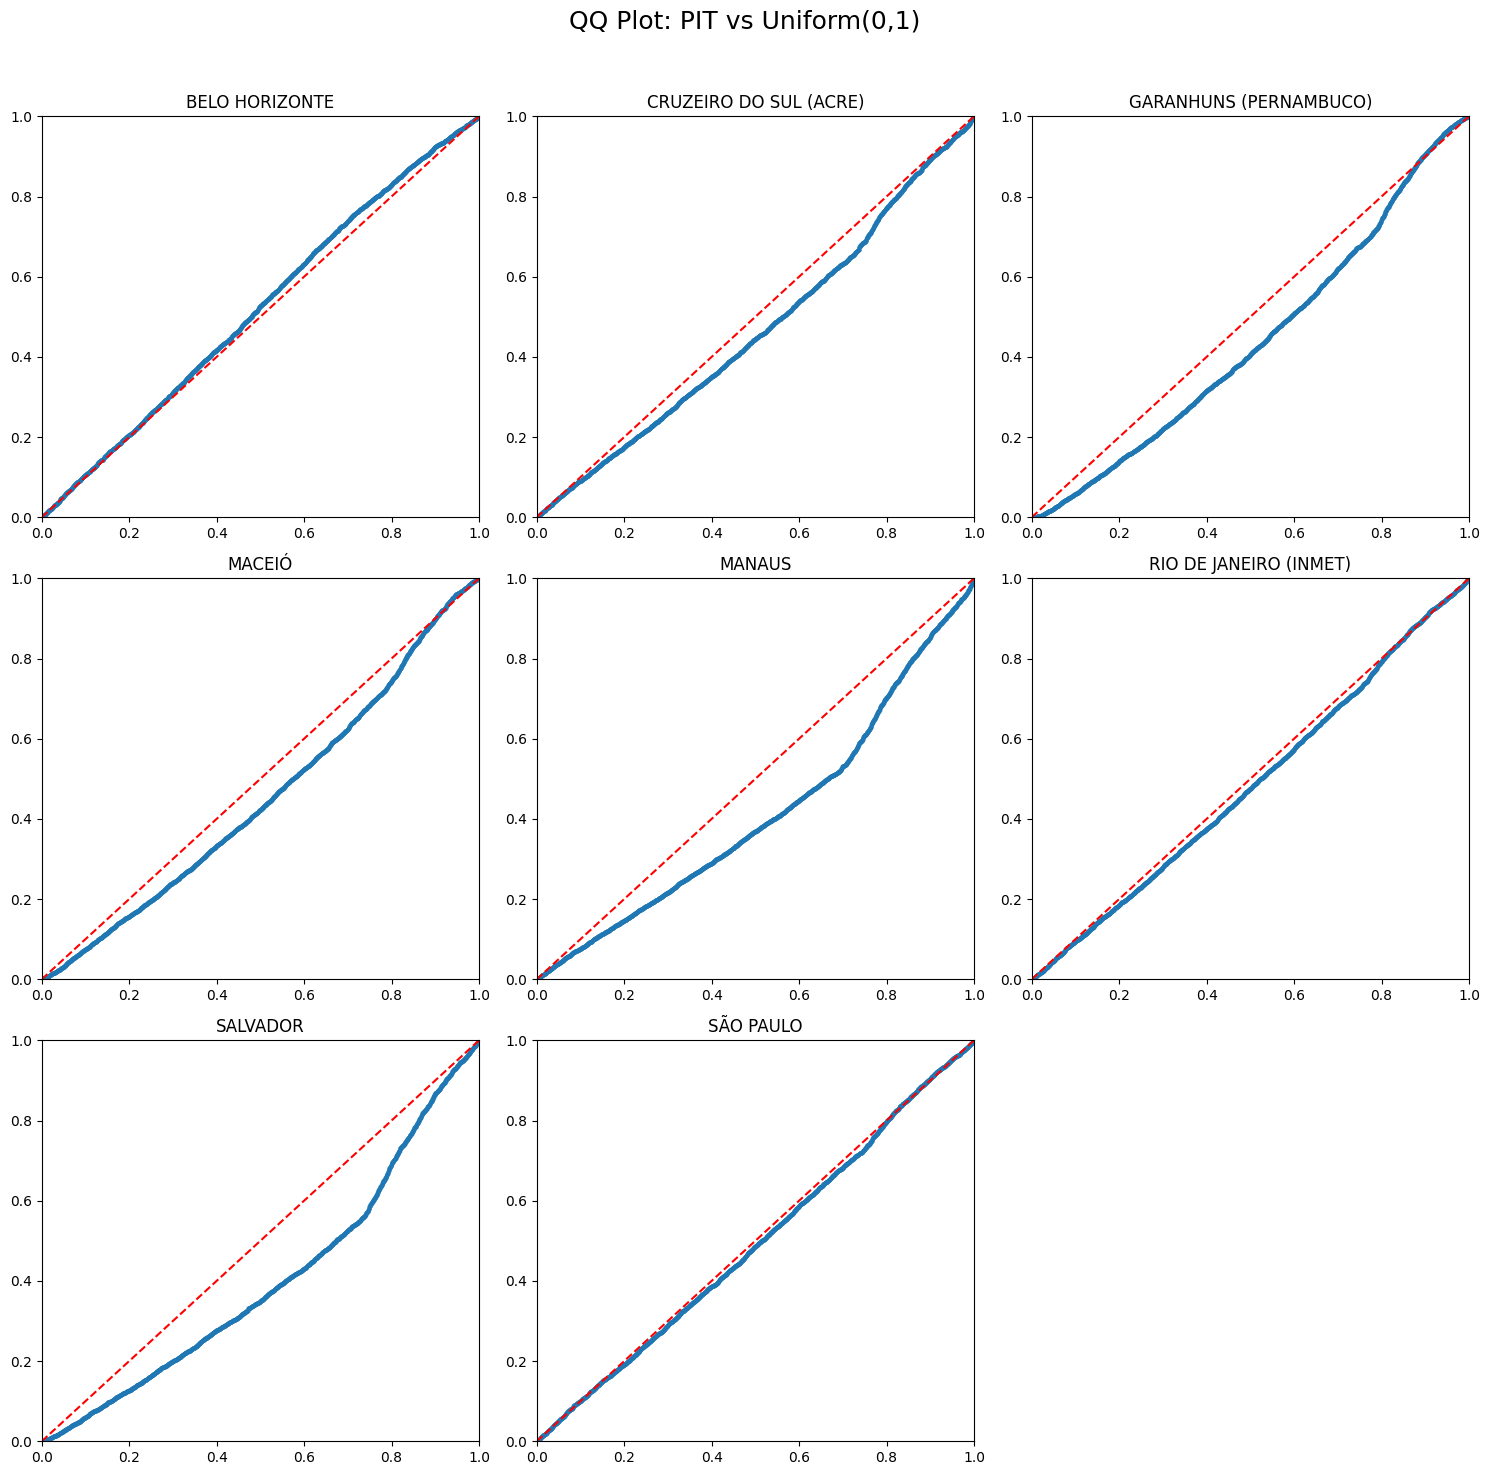

In [100]:
import math
import matplotlib.pyplot as plt

n_models = len(results)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]
    res = result[0]

    # --- (your parameter extraction block stays the same) ---
    # assume pit already computed exactly as in your code

    pit_sorted = np.sort(pits[idx_plot])
    n = len(pit_sorted)
    u_theoretical = (np.arange(1, n+1) - 0.5) / n

    ax.plot(u_theoretical, pit_sorted, 'o', alpha=0.5, markersize=2)
    ax.plot([0,1], [0,1], 'r--')
    ax.set_title(k)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

fig.suptitle("QQ Plot: PIT vs Uniform(0,1)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("QQ_PIT_mosaic.png", dpi=300)
plt.show()


In [90]:
quant

[array([ 4.38142685,  1.18467526,  1.01252472, ..., -0.10284096,
         0.16455491,  0.73438487], shape=(3644,)),
 array([ 6.36134089,  4.02716475,  3.75683073, ..., -0.21957812,
        -0.02158814,  0.33054195], shape=(3644,)),
 array([ 6.36134089,  2.95663978,  2.6777053 , ..., -1.00127176,
        -0.08269818,  0.32686872], shape=(3644,)),
 array([ 5.35714131,  1.34667368,  1.33465419, ..., -0.72016777,
        -0.35565543,  0.18595128], shape=(3644,)),
 array([ 6.32799974,  2.41186215,  2.29401535, ..., -0.33921149,
        -0.23919014,  0.06677265], shape=(3644,)),
 array([6.36134089, 5.4677635 , 4.97045354, ..., 0.01013661, 0.08282726,
        0.59798661], shape=(3644,)),
 array([ 6.1821382 ,  2.33618385,  2.13459925, ..., -0.64397419,
        -0.26199611,  0.14854622], shape=(3644,)),
 array([ 6.36134089,  2.83696646,  2.64996631, ..., -0.03248104,
         0.09291784,  0.53023132], shape=(3644,)),
 array([ 6.36134089,  2.83696646,  2.64996631, ..., -0.03248104,
         0.09

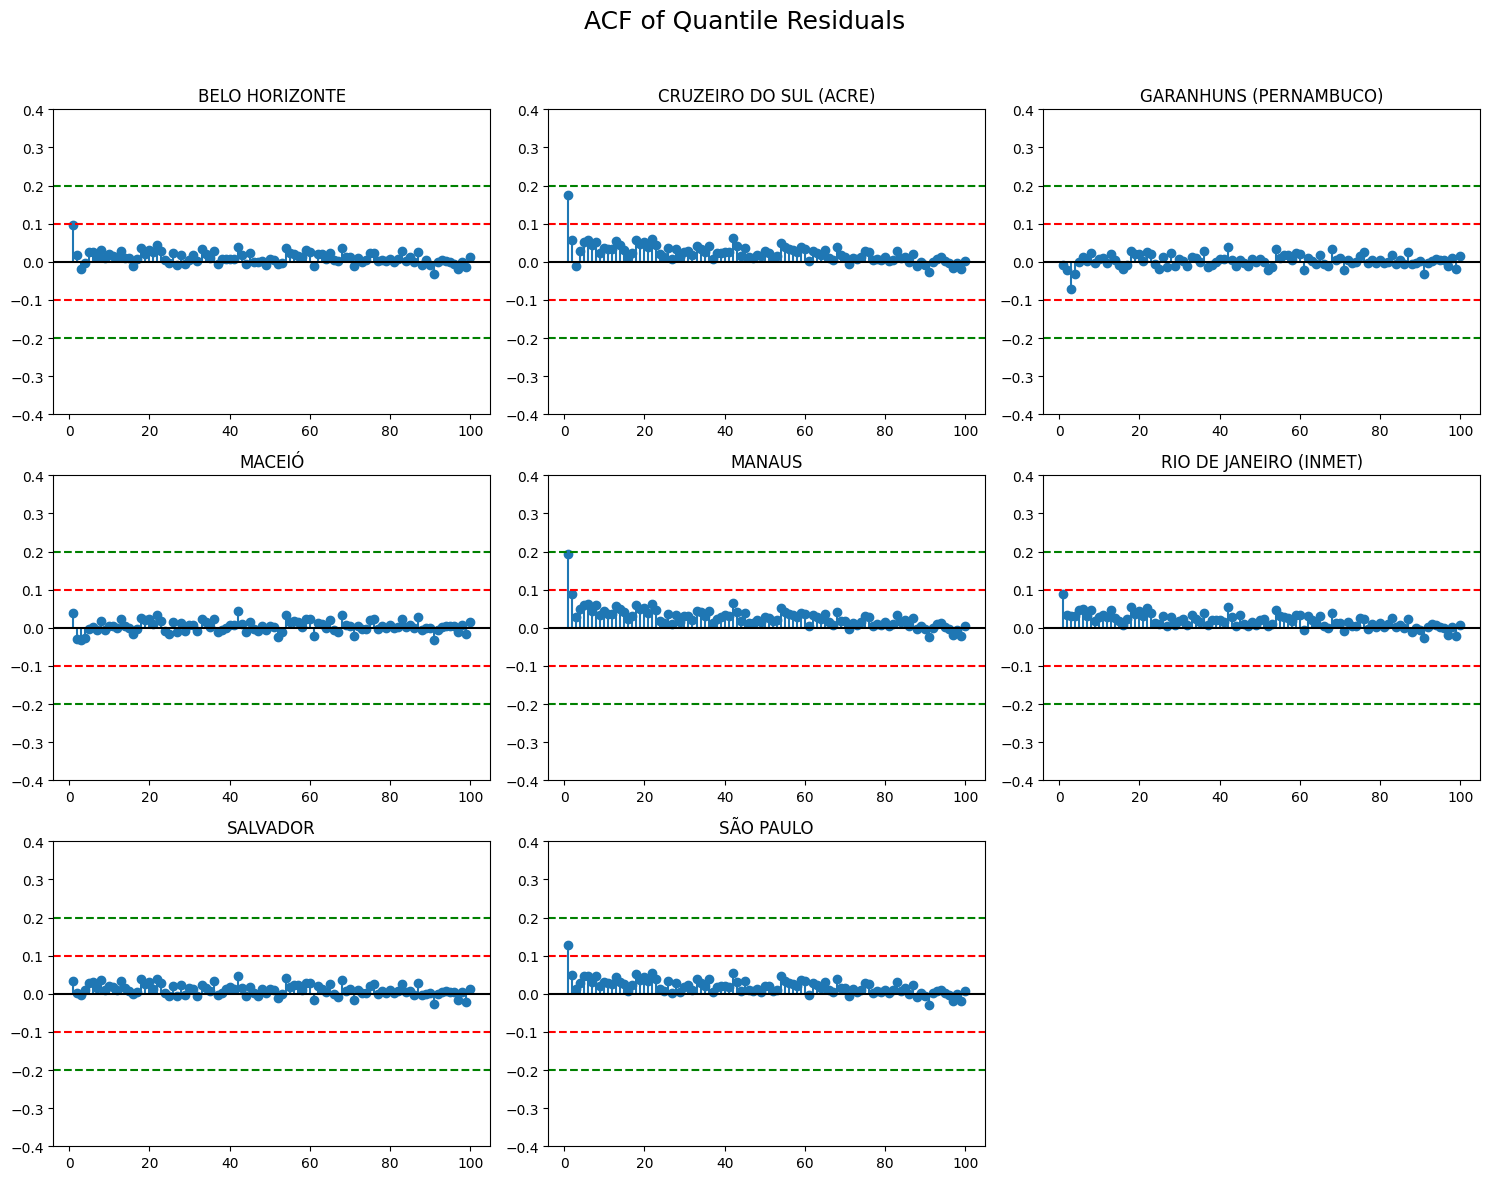

In [91]:
from statsmodels.tsa.stattools import acf

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]

    qr = quant[idx_plot]  # stored earlier

    nlags = 100  # 400 too crowded in mosaic
    acf_vals = acf(qr, nlags=nlags, fft=True)
    acf_vals_no0 = acf_vals[1:]
    lags = np.arange(1, nlags+1)
    
    conf01 = 0.1
    conf02 = 0.2

    ax.stem(lags, acf_vals_no0, basefmt=" ")
    ax.axhline(0, color="black")
    ax.axhline(conf01, color="red", linestyle="--")
    ax.axhline(-conf01, color="red", linestyle="--")
    ax.axhline(conf02, color="green", linestyle="--")
    ax.axhline(-conf02, color="green", linestyle="--")

    ax.set_title(k)
    ax.set_ylim(-0.4, 0.4)

fig.suptitle("ACF of Quantile Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ACF_quantile_mosaic.png", dpi=300)
plt.show()


In [92]:
quant

[array([ 4.38142685,  1.18467526,  1.01252472, ..., -0.10284096,
         0.16455491,  0.73438487], shape=(3644,)),
 array([ 6.36134089,  4.02716475,  3.75683073, ..., -0.21957812,
        -0.02158814,  0.33054195], shape=(3644,)),
 array([ 6.36134089,  2.95663978,  2.6777053 , ..., -1.00127176,
        -0.08269818,  0.32686872], shape=(3644,)),
 array([ 5.35714131,  1.34667368,  1.33465419, ..., -0.72016777,
        -0.35565543,  0.18595128], shape=(3644,)),
 array([ 6.32799974,  2.41186215,  2.29401535, ..., -0.33921149,
        -0.23919014,  0.06677265], shape=(3644,)),
 array([6.36134089, 5.4677635 , 4.97045354, ..., 0.01013661, 0.08282726,
        0.59798661], shape=(3644,)),
 array([ 6.1821382 ,  2.33618385,  2.13459925, ..., -0.64397419,
        -0.26199611,  0.14854622], shape=(3644,)),
 array([ 6.36134089,  2.83696646,  2.64996631, ..., -0.03248104,
         0.09291784,  0.53023132], shape=(3644,)),
 array([ 6.36134089,  2.83696646,  2.64996631, ..., -0.03248104,
         0.09

In [54]:
from scipy import stats

In [96]:
list(results.keys())

['BELO HORIZONTE',
 'CRUZEIRO DO SUL (ACRE)',
 'GARANHUNS (PERNAMBUCO)',
 'MACEIÓ',
 'MANAUS',
 'RIO DE JANEIRO (INMET)',
 'SALVADOR',
 'SÃO PAULO']

In [97]:
[stats.jarque_bera(q).pvalue for q in quant]

[np.float64(0.11532221777910186),
 np.float64(8.555524408343477e-11),
 np.float64(6.56275251497437e-17),
 np.float64(2.1375360280067896e-09),
 np.float64(2.806896364336939e-21),
 np.float64(2.070839109606697e-15),
 np.float64(1.094046598453341e-19),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679),
 np.float64(0.0004807625455968679)]

In [101]:
import pandas as pd
from scipy import stats


jb_table = pd.DataFrame({
    "model_key": list(results.keys()),
    "jb_pvalue": [stats.jarque_bera(q).pvalue for q in quant]
})

print(jb_table.to_latex(index=False, float_format="%.4g"))

\begin{tabular}{lr}
\toprule
model_key & jb_pvalue \\
\midrule
BELO HORIZONTE & 0.1153 \\
CRUZEIRO DO SUL (ACRE) & 8.556e-11 \\
GARANHUNS (PERNAMBUCO) & 6.563e-17 \\
MACEIÓ & 2.138e-09 \\
MANAUS & 2.807e-21 \\
RIO DE JANEIRO (INMET) & 2.071e-15 \\
SALVADOR & 1.094e-19 \\
SÃO PAULO & 0.0004808 \\
\bottomrule
\end{tabular}



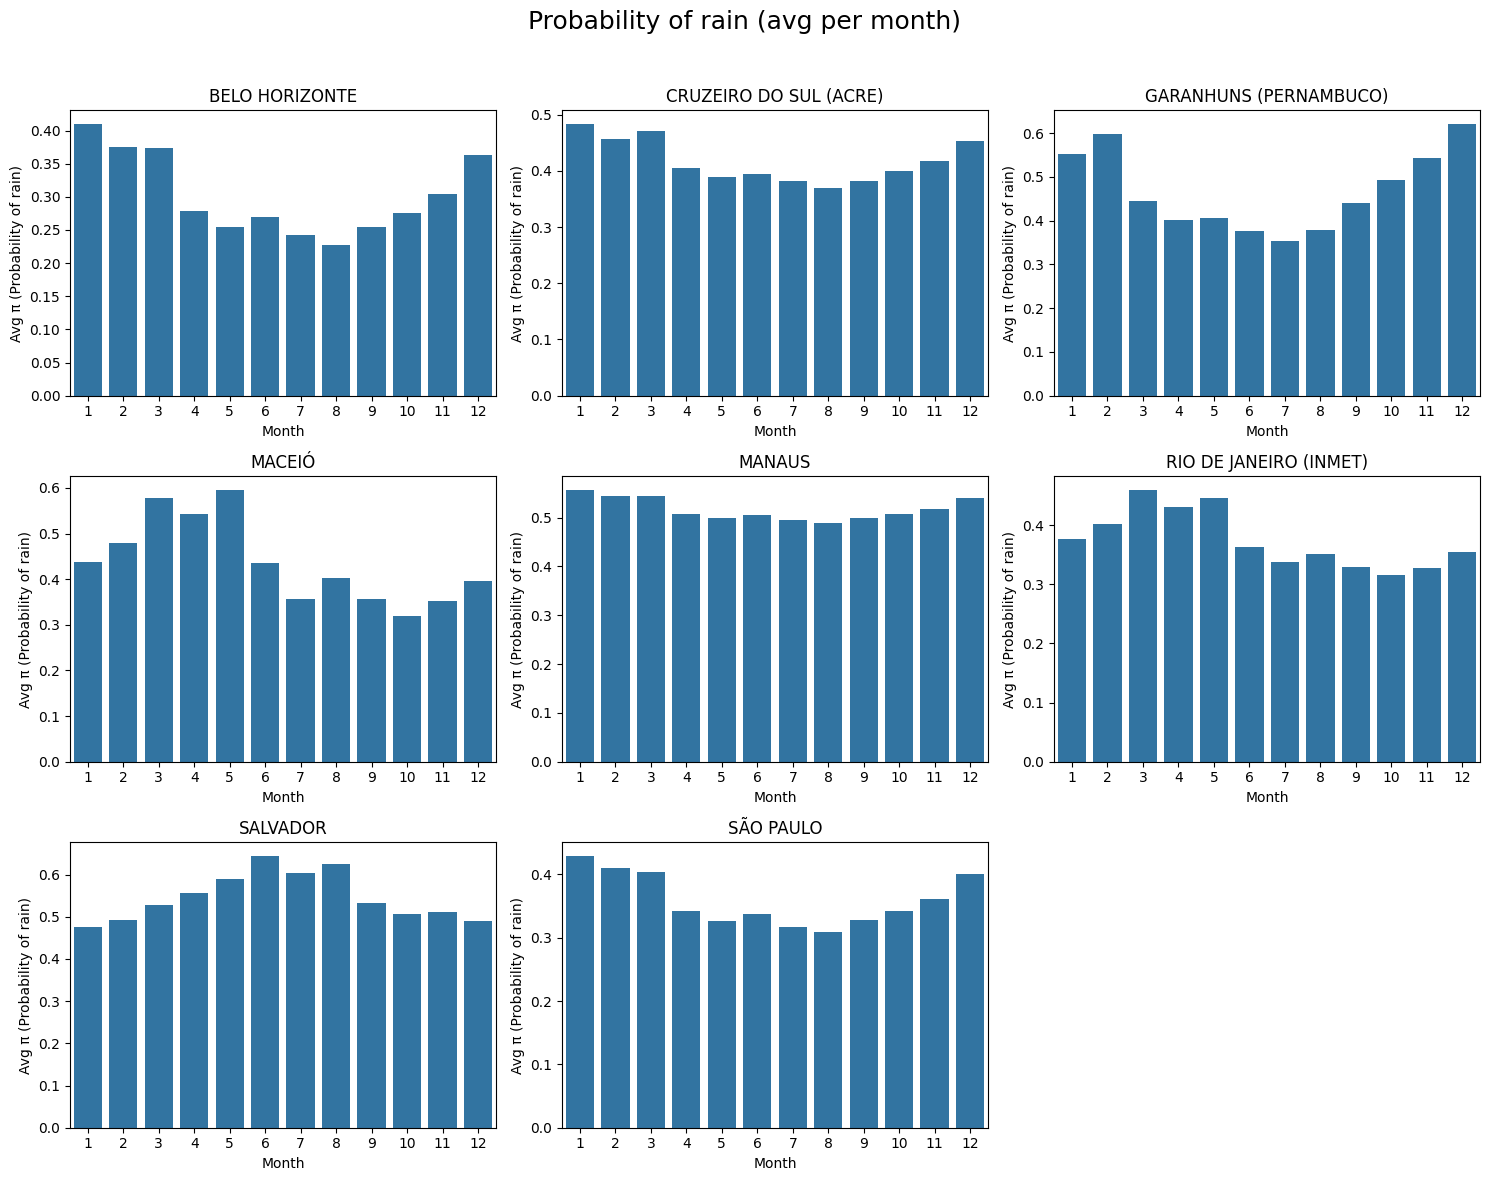

<Figure size 640x480 with 0 Axes>

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import math

# --- First collect valid files ---
files = [
    f for f in os.listdir(INPUT)
    if f.split("_")[-1] == "train.csv"
]

n = len(files)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()  # make indexing easy

j = 0

for i, file in enumerate(files):
    
    loc = file.split("_")[-2]
    
    df = pd.read_csv(os.path.join(INPUT, file), sep=";").iloc[3:]
    df['pi'] = pis[j]
    
    df['Mes'] = pd.to_datetime(
        df['Data Medicao'], 
        format="%d/%m/%Y"
    ).dt.month
    
    ht = df.groupby("Mes")['pi'].mean()
    
    ax = axes[i]
    sns.barplot(x=ht.index, y=ht.values, ax=ax)
    
    ax.set_title(f"{loc}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Avg π (Probability of rain)")
    
    j += 1

# --- Remove empty axes if any ---
for k in range(i+1, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle("Probability of rain (avg per month)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Pi_mosaic.png", dpi=300)
plt.show()


plt.tight_layout()
plt.show()


In [113]:
df['Mes'] = pd.to_datetime(df['Data Medicao'], format="%d/%m/%Y").dt.month

In [115]:
df.groupby("Mes")['pi'].mean()

Mes
1     0.429249
2     0.410510
3     0.403983
4     0.342944
5     0.326392
6     0.336776
7     0.317774
8     0.308818
9     0.327347
10    0.342027
11    0.361308
12    0.401143
Name: pi, dtype: float64

## Simulation

In [123]:
def unpack_theta(theta, K, tvp, harmonics):
    idx = 0

    kappas_tvp = np.zeros(4)

    mu0_phi   = theta[idx]; idx += 1
    c_phi     = theta[idx]; idx += 1
    alpha_phi = theta[idx]; idx += 1
    kappa_phi = theta[idx]; idx += 1

    if len(tvp) > 0:
        for v in tvp:
            kappas_tvp[v-1] = theta[idx]
            idx += 1

    kappa_gamma_phi = theta[idx]; idx += 1

    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    gamma_init = theta[idx]; idx += 1
    xi_init    = theta[idx]; idx += 1
    zeta_init  = theta[idx]; idx += 1

    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return {
        "mu0_phi": mu0_phi,
        "c_phi": c_phi,
        "alpha_phi": alpha_phi,
        "kappa_phi": kappa_phi,
        "kappas_tvp": kappas_tvp,
        "kappa_gamma_phi": kappa_gamma_phi,
        "omega0": omega0,
        "rho": rho,
        "omega_y": omega_y,
        "gamma_init": gamma_init,
        "xi_init": xi_init,
        "zeta_init": zeta_init,
        "gamma0_phi": gamma0_phi,
        "gamma_star0_phi": gamma_star0_phi,
    }


In [129]:
def rvs(phi, gamma, xi, zeta, size=1, **kwargs):
    """
    Random sampling from GB2 distribution using Beta transformation.
    """
    
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    # Draw from Beta
    U = np.random.beta(a, b, size=size)

    # Avoid numerical explosion near 1
    eps = 1e-12
    U = np.clip(U, eps, 1 - eps)

    # Transform
    Y = sigma * (U / (1 - U)) ** (1 / p)

    if size == 1:
        return Y.item()

    return Y


In [162]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # π dynamics
    omega0,
    rho,
    omega_y,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    harmonics,
    period,
    y,
    time_varying_parameters,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t
    - Persistent ARX logit π_t
    - Optional TVP for (gamma, xi, zeta)
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    n_eff = T - K

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # ===== 1. Update TVP parameters FIRST =====
        if i > 0:
            gamma[i] = gamma[i-1]
            xi[i] = xi[i-1]
            zeta[i] = zeta[i-1]

            if 2 in time_varying_parameters:
                gamma[i] += kappas_tvp[1] * score_gamma[i-1]
            if 3 in time_varying_parameters:
                xi[i] += kappas_tvp[2] * score_xi[i-1]
            if 4 in time_varying_parameters:
                zeta[i] += kappas_tvp[3] * score_zeta[i-1]

        # validity
        if np.exp(zeta[i]) <= np.exp(gamma[i]):
            return 1e12

        # ===== 2. φ dynamics =====
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # ===== 3. π dynamics =====
        y_lags = y[t-K:t][::-1]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ===== 4. Likelihood =====
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t],
                    phi=phi[i],
                    gamma=gamma[i],
                    xi=xi[i],
                    zeta=zeta[i],
                )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ===== 5. Scores =====
        if y[t] > 0:
            scores = gb2.score(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
        else:
            score_phi[i] = 0.0
            score_gamma[i] = 0.0
            score_xi[i] = 0.0
            score_zeta[i] = 0.0

        # ===== 6. GAS update for φ =====
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ===== 7. Seasonal φ =====
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = np.cos(lam) * g + np.sin(lam) * gs + kappa_gamma_phi * score_phi[i]
            gamma_star_phi[j] = np.cos(lam) * gs - np.sin(lam) * g + kappa_gamma_phi * score_phi[i]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik / n_eff

    elif mode == "filter":
        return {
            "mu_phi": mu_phi[:-1],
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "pi": pi,
            "eta": eta,
            "score_xi": score_xi,
            "mu_phi_last": mu_phi[n_eff],     # last updated mu_phi
            "gamma_last": gamma[n_eff-1],
            "xi_last": xi[n_eff-1],
            "zeta_last": zeta[n_eff-1],
            "eta_last": eta[n_eff-1],
            "gamma_phi_last": gamma_phi.copy(),
            "gamma_star_phi_last": gamma_star_phi.copy(),
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [167]:
def simulate_path_zagb2(theta, y, K, tvp, harmonics, period, H=730):

    params = unpack_theta(theta, K, tvp, harmonics)

    # --- Filter to get last states ---
    out = iterate_zagb2(
        mu0_phi=params["mu0_phi"],
        gamma0_phi=params["gamma0_phi"],
        gamma_star0_phi=params["gamma_star0_phi"],
        alpha_phi=params["alpha_phi"],
        kappa_phi=params["kappa_phi"],
        kappas_tvp=params["kappas_tvp"],
        c_phi=params["c_phi"],
        kappa_gamma_phi=params["kappa_gamma_phi"],
        omega0=params["omega0"],
        rho=params["rho"],
        omega_y=params["omega_y"],
        gamma_init=params["gamma_init"],
        xi_init=params["xi_init"],
        zeta_init=params["zeta_init"],
        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,
        mode="filter"
    )

    # --- Extract last filtered states ---
    mu_phi = out["mu_phi"][-1]
    eta = out["eta"][-1]

    gamma = out["gamma"][-1]
    xi = out["xi"][-1]
    zeta = out["zeta"][-1]

    gamma_phi = out["gamma_phi_last"].copy()
    gamma_star_phi = out["gamma_star_phi_last"].copy()

    score_xi = out["score_xi"][-1]

    y_lags = list(y[-K:])

    sim = np.zeros(H)
    gb2 = GB2LogLinkDistribution()
    rng = np.random.default_rng()

    for h in range(H):

        # --- φ ---
        phi = mu_phi + np.sum(gamma_phi)

        # --- π ---
        eta = (
            params["omega0"]
            + params["rho"] * eta
            + np.dot(params["omega_y"], y_lags[::-1])
        )
        pi = expit(eta)

        # --- Draw from ZAGB2 ---
        u = rng.uniform()

        if u < 1 - pi:
            y_new = 0.0
            scores = np.zeros(4)
        else:
            y_new = rvs(
                phi=phi,
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            scores = gb2.score(y_new, phi=phi, gamma=gamma, xi=xi, zeta=zeta)

        sim[h] = y_new

        # --- Update φ GAS ---
        mu_phi = (
            params["c_phi"]
            + params["alpha_phi"] * mu_phi
            + params["kappa_phi"] * scores[0]
        )

        # --- Seasonal φ ---
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = (
                np.cos(lam) * g
                + np.sin(lam) * gs
                + params["kappa_gamma_phi"] * scores[0]
            )

            gamma_star_phi[j] = (
                np.cos(lam) * gs
                - np.sin(lam) * g
                + params["kappa_gamma_phi"] * scores[0]
            )

        # --- TVP updates ---
        if 2 in tvp:
            gamma += params["kappas_tvp"][1] * scores[1]
        if 3 in tvp:
            xi += params["kappas_tvp"][2] * scores[2]
        if 4 in tvp:
            zeta += params["kappas_tvp"][3] * scores[3]

        # --- Update lags ---
        y_lags = [y_new] + y_lags[:-1]

    return sim


In [164]:
results

{'BELO HORIZONTE': [  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    success: True
     status: 0
        fun: 1.5459538894843485
          x: [ 2.661e+00  5.397e-01 ...  2.222e-04 -3.863e-04]
        nit: 9
        jac: [-5.205e-03 -3.023e-02 ... -1.751e-04  3.420e-04]
       nfev: 490
       njev: 14
   hess_inv: <34x34 LbfgsInvHessProduct with dtype=float64>],
 'CRUZEIRO DO SUL (ACRE)': [  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    success: True
     status: 0
        fun: 2.6047806313131474
          x: [ 2.464e+00  5.177e-01 ... -8.945e-06 -2.435e-05]
        nit: 5
        jac: [-1.261e-02  4.631e-02 ...  1.229e-03  2.679e-03]
       nfev: 385
       njev: 11
   hess_inv: <34x34 LbfgsInvHessProduct with dtype=float64>],
 'GARANHUNS (PERNAMBUCO)': [  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
    success: True
     status: 0
        fun: 1.8157348615476505
          x: [ 1.815e+00  5.594e-01 ...  2.618e-03 -4.128e-04]
  

In [168]:
y_dict = {}

for i,file in enumerate(os.listdir(INPUT)):
    
    loc = file.split("_")[-2]
     
    if file.split("_")[-1] == "train.csv":
        
        print("Working on " + loc)
        
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])
        
        y_dict[loc] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values

Working on BELO HORIZONTE
Working on CRUZEIRO DO SUL (ACRE)
Working on GARANHUNS (PERNAMBUCO)
Working on MACEIÓ
Working on MANAUS
Working on RIO DE JANEIRO (INMET)
Working on SALVADOR
Working on SÃO PAULO


In [170]:
H = 730
Nsim = 1000

forecast_mean = {}
forecast_lower = {}
forecast_upper = {}

for loc, res_list in results.items():

    print("Simulating", loc)

    res = res_list[0]
    theta = res.x
    y = y_dict[loc]  # you must store y per location

    sims = np.zeros((Nsim, H))

    for i in range(Nsim):
        sims[i] = simulate_path_zagb2(
            theta, y, 3, [3], harmonics, period, H
        )

    forecast_mean[loc] = sims.mean(axis=0)
    forecast_lower[loc] = np.quantile(sims, 0.025, axis=0)
    forecast_upper[loc] = np.quantile(sims, 0.975, axis=0)


Simulating BELO HORIZONTE
Simulating CRUZEIRO DO SUL (ACRE)
Simulating GARANHUNS (PERNAMBUCO)
Simulating MACEIÓ
Simulating MANAUS
Simulating RIO DE JANEIRO (INMET)
Simulating SALVADOR
Simulating SÃO PAULO


In [178]:
forecast_upper

{'BELO HORIZONTE': array([  52.41652104,   46.74803458,   60.51917543,   62.80350922,
          67.44128271,   86.38665541,   80.70802172,  102.61171563,
          85.91979375,  105.50858941,  131.76521138,  141.36139606,
         162.9708908 ,  153.94628998,  179.82635722,  114.74583371,
         127.4517626 ,  119.17083779,  174.98629855,  157.71358241,
         134.07667788,  155.60103042,  131.15713596,  157.74422994,
         122.6972199 ,  123.37547822,  120.85737508,  144.2131198 ,
         115.19202335,  137.17133535,   94.71999007,  130.23299119,
          99.01691531,  107.02504975,   84.61443024,   96.06649365,
         101.80020078,  100.79615136,  117.36468685,   88.75545276,
         102.0371422 ,   93.99468633,   97.56644811,  110.95737217,
         107.71676257,  136.07293249,  121.7575354 ,  140.85852952,
         146.23960334,  158.67744348,  132.67816171,  150.97771767,
         126.5888432 ,  160.55780096,  113.76559214,  130.98517727,
         122.11820452,   92.83

In [179]:
pd.DataFrame(forecast_upper).to_csv("forecast_upper.csv")
pd.DataFrame(forecast_lower).to_csv("forecast_lower.csv")
pd.DataFrame(forecast_mean).to_csv("forecast_mean.csv")

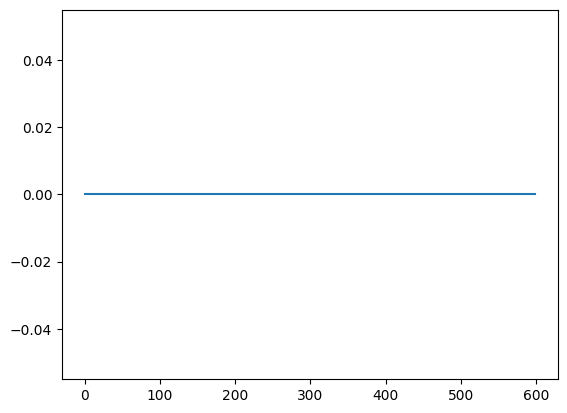

In [176]:
plt.plot(forecast_lower["GARANHUNS (PERNAMBUCO)"][0:600])